# One Pixel Attack: ResNet18 на Imagewoof

Сравнение исходной и FGSM-дообученной моделей в untargeted и targeted режимах. Ноутбук рассчитан на Kaggle GPU.

In [1]:
!pip install lightning -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 688.2 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 5.6 MB/s eta 0:00:0000:0100:01


In [10]:
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Callable, Optional
import copy
import csv
import hashlib
import json
import tarfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import lightning as L
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

SEED = 42
L.seed_everything(SEED, workers=True)
np.random.seed(SEED)

IMAGEWOOF_ARCHIVE = Path('/kaggle/input/datasets/renrgaming2000/imagewoof2-329/imagewoof2-320.tgz')
WEIGHTS_DIR = Path('/kaggle/input/datasets/notquartzz/weights-aa')
BASELINE_WEIGHTS = WEIGHTS_DIR / 'resnet18_imagewoof_best.pth'
ROBUST_WEIGHTS = WEIGHTS_DIR / 'resnet18_imagewoof_fgsm_robust (1).pth'
KAGGLE_INPUT = Path('/kaggle/input')
EXTRACT_DIR = Path('/tmp/imagewoof_onepixel')
OUTPUT_DIR = Path('/kaggle/working/imagewoof_onepixel')
EXAMPLES_DIR = OUTPUT_DIR / 'examples'

IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2
MAX_ATTACK_SAMPLES = 50
POPULATION_SIZE = 100
GENERATIONS = 50
DIFFERENTIAL_WEIGHT = 0.5
TARGET_THRESHOLD = 0.90
ORIGINAL_THRESHOLD = 0.05
PREDICT_BATCH_SIZE = 32
EXAMPLES_PER_COMBINATION = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EXAMPLES_DIR.mkdir(parents=True, exist_ok=True)
print('Device:', DEVICE)
print('Maximum evaluations per attack:', 1 + POPULATION_SIZE * (GENERATIONS + 1))

Seed set to 42


Device: cuda
Maximum evaluations per attack: 5101


## Датасет Imagewoof

In [11]:
def find_imagewoof_archive(configured_path: Path) -> Path:
    if configured_path.is_file():
        return configured_path
    candidates = sorted(
        path for path in KAGGLE_INPUT.rglob('*')
        if path.is_file() and 'imagewoof' in path.name.lower()
        and (path.name.endswith('.tgz') or path.name.endswith('.tar.gz'))
    )
    if len(candidates) != 1:
        raise FileNotFoundError(
            f'Ожидался один архив Imagewoof. Настроенный путь: {configured_path}. Найдено: {candidates}'
        )
    return candidates[0]


def resolve_dataset_root(search_root: Path) -> Path:
    if (search_root / 'train').is_dir() and (search_root / 'val').is_dir():
        return search_root
    candidates = sorted(
        path.parent for path in search_root.rglob('train')
        if path.is_dir() and (path.parent / 'val').is_dir()
    ) if search_root.exists() else []
    preferred = [path for path in candidates if 'imagewoof' in str(path).lower()]
    if len(preferred) == 1:
        return preferred[0]
    if len(candidates) == 1:
        return candidates[0]
    raise FileNotFoundError(f'Не найден единственный Imagewoof train/val в {search_root}: {candidates}')


def prepare_imagewoof() -> Path:
    try:
        root = resolve_dataset_root(EXTRACT_DIR)
        print('Используется уже распакованный датасет:', root)
        return root
    except FileNotFoundError:
        pass
    archive_path = find_imagewoof_archive(IMAGEWOOF_ARCHIVE)
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    print(f'Распаковка {archive_path} в {EXTRACT_DIR} ...')
    with tarfile.open(archive_path, 'r:*') as archive:
        archive.extractall(EXTRACT_DIR, filter='data')
    root = resolve_dataset_root(EXTRACT_DIR)
    print('Dataset root:', root)
    return root


class ImagewoofDataModule(L.LightningDataModule):
    def __init__(self, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
        super().__init__()
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.val_transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(IMAGE_SIZE),
            transforms.ToTensor(),
        ])

    def prepare_data(self):
        self.data_root = prepare_imagewoof()

    def setup(self, stage=None):
        if not hasattr(self, 'data_root'):
            self.prepare_data()
        self.val_set = datasets.ImageFolder(self.data_root / 'val', transform=self.val_transform)
        if len(self.val_set.classes) != 10:
            raise ValueError(f'Ожидалось 10 классов, найдено {len(self.val_set.classes)}')

    def test_dataloader(self):
        return DataLoader(
            self.val_set, batch_size=self.batch_size, shuffle=False,
            num_workers=self.num_workers, pin_memory=torch.cuda.is_available(),
            persistent_workers=self.num_workers > 0, drop_last=False,
        )

    def val_dataloader(self):
        return self.test_dataloader()


dm = ImagewoofDataModule()
dm.prepare_data()
dm.setup('test')
DATASET_ROOT = dm.data_root
val_set = dm.val_set
val_loader = dm.val_dataloader()
sample_x, sample_y = next(iter(val_loader))
assert sample_x.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)
assert 0.0 <= sample_x.min().item() <= sample_x.max().item() <= 1.0
print(f'Validation images: {len(val_set):,}')
print('Classes:', val_set.class_to_idx)

Используется уже распакованный датасет: /tmp/imagewoof_onepixel/imagewoof2-320
Validation images: 3,929
Classes: {'n02086240': 0, 'n02087394': 1, 'n02088364': 2, 'n02089973': 3, 'n02093754': 4, 'n02096294': 5, 'n02099601': 6, 'n02105641': 7, 'n02111889': 8, 'n02115641': 9}


## Модели и строгая загрузка весов

In [12]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer('mean', torch.tensor(mean).view(1, -1, 1, 1))
        self.register_buffer('std', torch.tensor(std).view(1, -1, 1, 1))

    def forward(self, x):
        return (x - self.mean) / self.std


class NormalizedModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.normalize = Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        )
        self.model = models.resnet18(weights=None, num_classes=num_classes)

    def forward(self, x):
        return self.model(self.normalize(x))


class ImagewoofClassifier(L.LightningModule):
    def __init__(self, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.model = NormalizedModel(num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def test_step(self, batch, batch_idx):
        images, labels = batch
        logits = self(images)
        accuracy = (logits.argmax(1) == labels).float().mean()
        self.log('test_acc', accuracy, on_epoch=True, batch_size=labels.size(0))


def validate_weights_paths():
    missing = [path for path in (BASELINE_WEIGHTS, ROBUST_WEIGHTS) if not path.is_file()]
    if missing:
        available = sorted(path for path in WEIGHTS_DIR.rglob('*') if path.is_file()) if WEIGHTS_DIR.exists() else []
        raise FileNotFoundError(f'Не найдены веса: {missing}. Файлы в {WEIGHTS_DIR}: {available}')


def read_checkpoint(path: Path):
    if not path.is_file():
        raise FileNotFoundError(f'Не найдены веса: {path}')
    try:
        checkpoint = torch.load(path, map_location='cpu', weights_only=True)
    except TypeError:
        checkpoint = torch.load(path, map_location='cpu')
    if not isinstance(checkpoint, dict):
        raise TypeError(f'Checkpoint должен быть словарём, получено: {type(checkpoint)}')
    state = checkpoint.get('state_dict', checkpoint.get('model_state_dict', checkpoint))
    if not isinstance(state, dict):
        raise TypeError('В checkpoint не найден state_dict')
    return checkpoint, {key.removeprefix('module.'): value for key, value in state.items()}


def load_weights_strict(model: NormalizedModel, path: Path):
    checkpoint, state = read_checkpoint(path)
    if 'model.normalize.mean' in state:
        state = {key.removeprefix('model.'): value for key, value in state.items()}
    if 'normalize.mean' in state and any(key.startswith('model.') for key in state):
        model.load_state_dict(state, strict=True)
        loaded_into = 'normalized_model'
    else:
        raw_state = {}
        for key, value in state.items():
            if key in {'normalize.mean', 'normalize.std'}:
                continue
            key = key.removeprefix('backbone.').removeprefix('model.model.')
            raw_state[key] = value
        model.model.load_state_dict(raw_state, strict=True)
        loaded_into = 'resnet18'
    metadata = {key: checkpoint[key] for key in ('epoch', 'val_acc', 'validation_accuracy') if key in checkpoint}
    print(f'Loaded strictly into {loaded_into}: {path}')
    if metadata:
        print('Checkpoint metadata:', metadata)
    return metadata


def model_fingerprint(model: nn.Module) -> str:
    digest = hashlib.sha256()
    for key, value in sorted(model.state_dict().items()):
        digest.update(key.encode('utf-8'))
        digest.update(value.detach().cpu().contiguous().numpy().tobytes())
    return digest.hexdigest()


validate_weights_paths()
baseline_module = ImagewoofClassifier()
robust_module = ImagewoofClassifier()
load_weights_strict(baseline_module.model, BASELINE_WEIGHTS)
load_weights_strict(robust_module.model, ROBUST_WEIGHTS)
baseline_module = baseline_module.to(DEVICE).eval().requires_grad_(False)
robust_module = robust_module.to(DEVICE).eval().requires_grad_(False)
models_by_name = {'before': baseline_module, 'after': robust_module}
fingerprints_before = {name: model_fingerprint(net) for name, net in models_by_name.items()}
with torch.inference_mode():
    for name, net in models_by_name.items():
        logits = net(sample_x[:2].to(DEVICE))
        assert logits.shape == (2, 10), (name, logits.shape)
print('Model output checks passed')

Loaded strictly into resnet18: /kaggle/input/datasets/notquartzz/weights-aa/resnet18_imagewoof_best.pth
Checkpoint metadata: {'epoch': 39, 'val_acc': 0.80580300330873}
Loaded strictly into normalized_model: /kaggle/input/datasets/notquartzz/weights-aa/resnet18_imagewoof_fgsm_robust (1).pth
Model output checks passed


## Lightning smoke-тест

In [13]:
for model_name, lightning_model in models_by_name.items():
    smoke_trainer = L.Trainer(
        fast_dev_run=True, accelerator='auto', devices=1, logger=False,
        enable_checkpointing=False, enable_model_summary=False,
    )
    smoke_trainer.test(lightning_model, datamodule=dm, verbose=False)
    lightning_model.to(DEVICE).eval().requires_grad_(False)
    print(f'Lightning smoke-test passed: {model_name}')
del smoke_trainer

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Используется уже распакованный датасет: /tmp/imagewoof_onepixel/imagewoof2-320


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Lightning smoke-test passed: before
Используется уже распакованный датасет: /tmp/imagewoof_onepixel/imagewoof2-320


Output()

Lightning smoke-test passed: after


## One Pixel Attack: Differential Evolution без crossover

In [14]:
PredictFn = Callable[[np.ndarray], np.ndarray]


def make_predict_probs(model: nn.Module, batch_size=PREDICT_BATCH_SIZE) -> PredictFn:
    @torch.inference_mode()
    def predict_probs(batch_uint8: np.ndarray) -> np.ndarray:
        if batch_uint8.dtype != np.uint8 or batch_uint8.ndim != 4 or batch_uint8.shape[-1] != 3:
            raise ValueError(f'Ожидается NHWC uint8 RGB, получено {batch_uint8.shape} {batch_uint8.dtype}')
        outputs = []
        for start in range(0, len(batch_uint8), batch_size):
            chunk = np.ascontiguousarray(batch_uint8[start:start + batch_size])
            x = torch.from_numpy(chunk).to(DEVICE, dtype=torch.float32)
            x = x.permute(0, 3, 1, 2) / 255.0
            outputs.append(torch.softmax(model(x), dim=1).cpu().numpy())
        return np.concatenate(outputs, axis=0)
    return predict_probs


predictors = {name: make_predict_probs(net) for name, net in models_by_name.items()}


@dataclass
class AttackResult:
    success: bool
    image: np.ndarray
    vector: np.ndarray
    original_class: int
    predicted_class: int
    probabilities: np.ndarray
    generations: int
    evaluations: int


def apply_population(image: np.ndarray, population: np.ndarray) -> np.ndarray:
    if image.dtype != np.uint8 or image.ndim != 3 or image.shape[2] != 3:
        raise ValueError('Ожидается RGB-изображение HxWx3 с dtype=uint8')
    height, width, _ = image.shape
    candidates = np.repeat(image[None, ...], len(population), axis=0)
    vectors = np.rint(population).astype(np.int32)
    xs = np.clip(vectors[:, 0], 0, width - 1)
    ys = np.clip(vectors[:, 1], 0, height - 1)
    rgb = np.clip(vectors[:, 2:5], 0, 255).astype(np.uint8)
    candidates[np.arange(len(population)), ys, xs] = rgb
    return candidates


def one_pixel_attack(
    image: np.ndarray,
    predict_probs: PredictFn,
    target_class: Optional[int] = None,
    population_size: int = POPULATION_SIZE,
    generations: int = GENERATIONS,
    differential_weight: float = DIFFERENTIAL_WEIGHT,
    target_threshold: float = TARGET_THRESHOLD,
    original_threshold: float = ORIGINAL_THRESHOLD,
    seed: int = SEED,
) -> AttackResult:
    if population_size < 4 or generations < 1:
        raise ValueError('Требуются population_size >= 4 и generations >= 1')
    rng = np.random.default_rng(seed)
    height, width, _ = image.shape
    original_probs = predict_probs(image[None, ...])[0]
    original_class = int(original_probs.argmax())
    if target_class is not None and target_class == original_class:
        raise ValueError('Целевой класс должен отличаться от исходного')

    population = np.empty((population_size, 5), dtype=np.float64)
    population[:, 0] = rng.uniform(0, width - 1, population_size)
    population[:, 1] = rng.uniform(0, height - 1, population_size)
    population[:, 2:5] = np.clip(rng.normal(128, 127, (population_size, 3)), 0, 255)
    lower = np.array([0, 0, 0, 0, 0], dtype=np.float64)
    upper = np.array([width - 1, height - 1, 255, 255, 255], dtype=np.float64)
    evaluations = 1

    def evaluate(candidate_population):
        nonlocal evaluations
        probabilities = predict_probs(apply_population(image, candidate_population))
        evaluations += len(candidate_population)
        fitness = (
            -probabilities[:, original_class]
            if target_class is None else probabilities[:, target_class]
        )
        return fitness, probabilities

    def threshold_reached(probabilities):
        if target_class is None:
            return probabilities[original_class] < original_threshold
        return probabilities[target_class] > target_threshold

    fitness, probabilities = evaluate(population)
    generation = 0
    best_idx = int(fitness.argmax())
    while generation < generations and not threshold_reached(probabilities[best_idx]):
        generation += 1
        children = np.empty_like(population)
        all_indices = np.arange(population_size)
        for index in range(population_size):
            pool = np.delete(all_indices, index)
            r1, r2, r3 = rng.choice(pool, size=3, replace=False)
            children[index] = population[r1] + differential_weight * (population[r2] - population[r3])
        children = np.clip(children, lower, upper)
        child_fitness, child_probabilities = evaluate(children)
        improved = child_fitness > fitness
        population[improved] = children[improved]
        fitness[improved] = child_fitness[improved]
        probabilities[improved] = child_probabilities[improved]
        best_idx = int(fitness.argmax())

    best_vector = population[best_idx]
    adversarial = apply_population(image, best_vector[None, :])[0]
    final_probs = probabilities[best_idx]
    predicted_class = int(final_probs.argmax())
    success = (
        predicted_class != original_class
        if target_class is None else predicted_class == target_class
    )
    return AttackResult(
        success=success, image=adversarial, vector=np.rint(best_vector).astype(np.int32),
        original_class=original_class, predicted_class=predicted_class,
        probabilities=final_probs, generations=generation, evaluations=evaluations,
    )

## Общая clean-correct выборка и smoke-тест

In [15]:
selected_images = []
selected_labels = []
selected_dataset_indices = []
dataset_offset = 0
for images, labels in val_loader:
    batch_uint8 = (images.mul(255).round().clamp(0, 255).byte().permute(0, 2, 3, 1).numpy())
    predictions = {name: predictor(batch_uint8).argmax(1) for name, predictor in predictors.items()}
    common_correct = np.ones(len(labels), dtype=bool)
    for prediction in predictions.values():
        common_correct &= prediction == labels.numpy()
    for local_index in np.flatnonzero(common_correct):
        selected_images.append(batch_uint8[local_index].copy())
        selected_labels.append(int(labels[local_index]))
        selected_dataset_indices.append(dataset_offset + int(local_index))
        if len(selected_images) >= MAX_ATTACK_SAMPLES:
            break
    dataset_offset += len(labels)
    if len(selected_images) >= MAX_ATTACK_SAMPLES:
        break

if len(selected_images) < MAX_ATTACK_SAMPLES:
    raise RuntimeError(f'Найдено только {len(selected_images)} общих clean-correct изображений')
selected_images = np.stack(selected_images)
selected_labels = np.asarray(selected_labels, dtype=np.int64)
target_rng = np.random.default_rng(SEED)
target_base = target_rng.integers(0, 9, size=len(selected_labels))
target_classes = target_base + (target_base >= selected_labels)
assert np.all(target_classes != selected_labels)
assert selected_images.dtype == np.uint8 and selected_images.shape[1:] == (IMAGE_SIZE, IMAGE_SIZE, 3)
print('Common clean-correct samples:', len(selected_images))

smoke = one_pixel_attack(
    selected_images[0], predictors['before'], target_class=None,
    population_size=8, generations=2, seed=SEED,
)
changed = np.any(smoke.image != selected_images[0], axis=2)
assert smoke.image.dtype == np.uint8 and smoke.image.shape == selected_images[0].shape
assert int(changed.sum()) <= 1
assert smoke.success == (smoke.predicted_class != smoke.original_class)
print('Smoke-test passed:', {'success': smoke.success, 'evaluations': smoke.evaluations})

Common clean-correct samples: 50
Smoke-test passed: {'success': False, 'evaluations': 25}


## Полный запуск: before/after × untargeted/targeted

In [16]:
records = []
successful_examples = []
saved_example_counts = {(model_name, mode): 0 for model_name in models_by_name for mode in ('untargeted', 'targeted')}
results_path = OUTPUT_DIR / 'onepixel_results.csv'

for model_name, predictor in predictors.items():
    for mode_index, mode in enumerate(('untargeted', 'targeted')):
        for sample_index, (image, true_class, target_class) in enumerate(
            zip(selected_images, selected_labels, target_classes)
        ):
            attack_target = None if mode == 'untargeted' else int(target_class)
            attack_seed = SEED + sample_index * 10 + mode_index
            before_probs = predictor(image[None, ...])[0]
            result = one_pixel_attack(
                image=image, predict_probs=predictor, target_class=attack_target,
                population_size=POPULATION_SIZE, generations=GENERATIONS,
                differential_weight=DIFFERENTIAL_WEIGHT, seed=attack_seed,
            )
            changed_positions = np.argwhere(np.any(result.image != image, axis=2))
            assert len(changed_positions) <= 1
            assert result.original_class == int(true_class)
            expected_success = (
                result.predicted_class != result.original_class
                if attack_target is None else result.predicted_class == attack_target
            )
            assert result.success == expected_success
            x, y, red, green, blue = result.vector.tolist()
            old_rgb = image[np.clip(y, 0, IMAGE_SIZE - 1), np.clip(x, 0, IMAGE_SIZE - 1)].tolist()
            record = {
                'model': model_name, 'mode': mode, 'sample_index': sample_index,
                'dataset_index': selected_dataset_indices[sample_index],
                'true_class': int(true_class), 'target_class': attack_target,
                'clean_prediction': result.original_class, 'adversarial_prediction': result.predicted_class,
                'success': bool(result.success), 'post_attack_correct': result.predicted_class == int(true_class),
                'clean_original_probability': float(before_probs[result.original_class]),
                'adversarial_original_probability': float(result.probabilities[result.original_class]),
                'clean_target_probability': None if attack_target is None else float(before_probs[attack_target]),
                'adversarial_target_probability': None if attack_target is None else float(result.probabilities[attack_target]),
                'generations': result.generations, 'evaluations': result.evaluations,
                'x': int(x), 'y': int(y), 'old_rgb': old_rgb, 'new_rgb': [int(red), int(green), int(blue)],
                'changed_pixels': int(len(changed_positions)),
            }
            records.append(record)
            pd.DataFrame(records).to_csv(results_path, index=False)
            key = (model_name, mode)
            if result.success and saved_example_counts[key] < EXAMPLES_PER_COMBINATION:
                successful_examples.append({**record, 'original': image.copy(), 'adversarial': result.image.copy()})
                saved_example_counts[key] += 1
            print(
                f'{model_name:>6} | {mode:>10} | {sample_index + 1:02d}/{len(selected_images)} | '
                f'success={result.success} | evals={result.evaluations}'
            )

results_df = pd.DataFrame(records)
display(results_df.head())

before | untargeted | 01/50 | success=False | evals=5101
before | untargeted | 02/50 | success=True | evals=5101
before | untargeted | 03/50 | success=False | evals=5101
before | untargeted | 04/50 | success=False | evals=5101
before | untargeted | 05/50 | success=False | evals=5101
before | untargeted | 06/50 | success=False | evals=5101
before | untargeted | 07/50 | success=False | evals=5101
before | untargeted | 08/50 | success=False | evals=5101
before | untargeted | 09/50 | success=False | evals=5101
before | untargeted | 10/50 | success=False | evals=5101
before | untargeted | 11/50 | success=False | evals=5101
before | untargeted | 12/50 | success=False | evals=5101
before | untargeted | 13/50 | success=False | evals=5101
before | untargeted | 14/50 | success=False | evals=5101
before | untargeted | 15/50 | success=False | evals=5101
before | untargeted | 16/50 | success=False | evals=5101
before | untargeted | 17/50 | success=False | evals=5101
before | untargeted | 18/50 | su

,model,mode,sample_index,dataset_index,true_class,target_class,clean_prediction,adversarial_prediction,success,post_attack_correct,...,adversarial_original_probability,clean_target_probability,adversarial_target_probability,generations,evaluations,x,y,old_rgb,new_rgb,changed_pixels
0,before,untargeted,0,0,0,NaN,0,0,False,True,...,0.741300,NaN,NaN,50,5101,175,135,"[105, 84, 67]","[200, 255, 120]",1
1,before,untargeted,1,1,0,NaN,0,7,True,False,...,0.362813,NaN,NaN,50,5101,95,29,"[251, 255, 254]","[0, 0, 0]",1
2,before,untargeted,2,2,0,NaN,0,0,False,True,...,0.544154,NaN,NaN,50,5101,37,87,"[67, 44, 27]","[255, 161, 255]",1
3,before,untargeted,3,3,0,NaN,0,0,False,True,...,0.774674,NaN,NaN,50,5101,168,34,"[47, 47, 47]","[200, 254, 255]",1
4,before,untargeted,4,5,0,NaN,0,0,False,True,...,0.642467,NaN,NaN,50,5101,101,17,"[14, 14, 16]","[255, 254, 255]",1


## Метрики и графики

,model,mode,samples,success_rate,robust_accuracy,mean_evaluations,median_evaluations,mean_generations
0,after,targeted,50,0.00%,100.00%,5101.0,5101.0,50.0
1,after,untargeted,50,0.00%,100.00%,5101.0,5101.0,50.0
2,before,targeted,50,2.00%,98.00%,5101.0,5101.0,50.0
3,before,untargeted,50,6.00%,94.00%,5101.0,5101.0,50.0


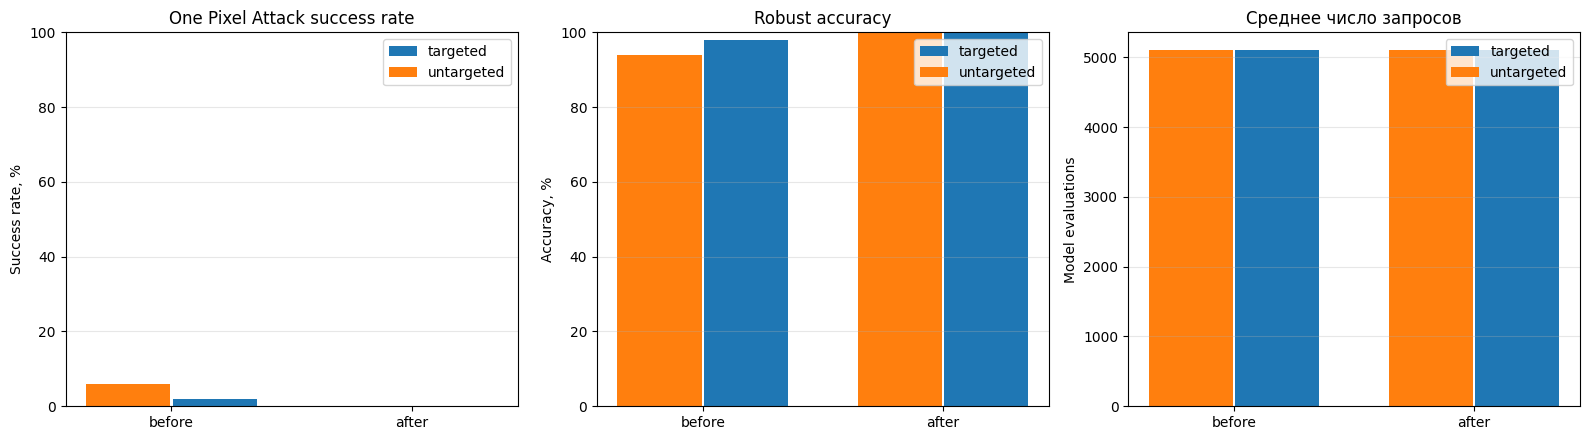

In [20]:
summary_df = (
    results_df.groupby(['model', 'mode'], as_index=False)
    .agg(
        samples=('success', 'size'),
        success_rate=('success', 'mean'),
        robust_accuracy=('post_attack_correct', 'mean'),
        mean_evaluations=('evaluations', 'mean'),
        median_evaluations=('evaluations', 'median'),
        mean_generations=('generations', 'mean'),
    )
)
summary_df.to_csv(OUTPUT_DIR / 'onepixel_summary.csv', index=False)
display(summary_df.style.format({
    'success_rate': '{:.2%}', 'robust_accuracy': '{:.2%}',
    'mean_evaluations': '{:.1f}', 'median_evaluations': '{:.1f}', 'mean_generations': '{:.1f}',
}))

configuration = {
    'seed': SEED, 'samples': MAX_ATTACK_SAMPLES, 'population_size': POPULATION_SIZE,
    'generations': GENERATIONS, 'differential_weight': DIFFERENTIAL_WEIGHT,
    'target_threshold': TARGET_THRESHOLD, 'original_threshold': ORIGINAL_THRESHOLD,
    'predict_batch_size': PREDICT_BATCH_SIZE, 'baseline_weights': str(BASELINE_WEIGHTS),
    'robust_weights': str(ROBUST_WEIGHTS), 'dataset_root': str(DATASET_ROOT),
}
with (OUTPUT_DIR / 'configuration.json').open('w', encoding='utf-8') as file:
    json.dump(configuration, file, ensure_ascii=False, indent=2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for mode, group in summary_df.groupby('mode'):
    ordered = group.set_index('model').loc[['before', 'after']]
    x_positions = np.arange(2) + (-0.18 if mode == 'untargeted' else 0.18)
    axes[0].bar(x_positions, ordered['success_rate'] * 100, width=0.35, label=mode)
    axes[1].bar(x_positions, ordered['robust_accuracy'] * 100, width=0.35, label=mode)
    axes[2].bar(x_positions, ordered['mean_evaluations'], width=0.35, label=mode)
axes[0].set_title('One Pixel Attack success rate')
axes[0].set_ylabel('Success rate, %')
axes[0].set_ylim(0, 100)
axes[1].set_title('Robust accuracy')
axes[1].set_ylabel('Accuracy, %')
axes[1].set_ylim(0, 100)
axes[2].set_title('Среднее число запросов')
axes[2].set_ylabel('Model evaluations')
for axis in axes:
    axis.set_xticks([0, 1], ['before', 'after'])
    axis.grid(axis='y', alpha=0.3)
    axis.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'onepixel_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

## Успешные примеры

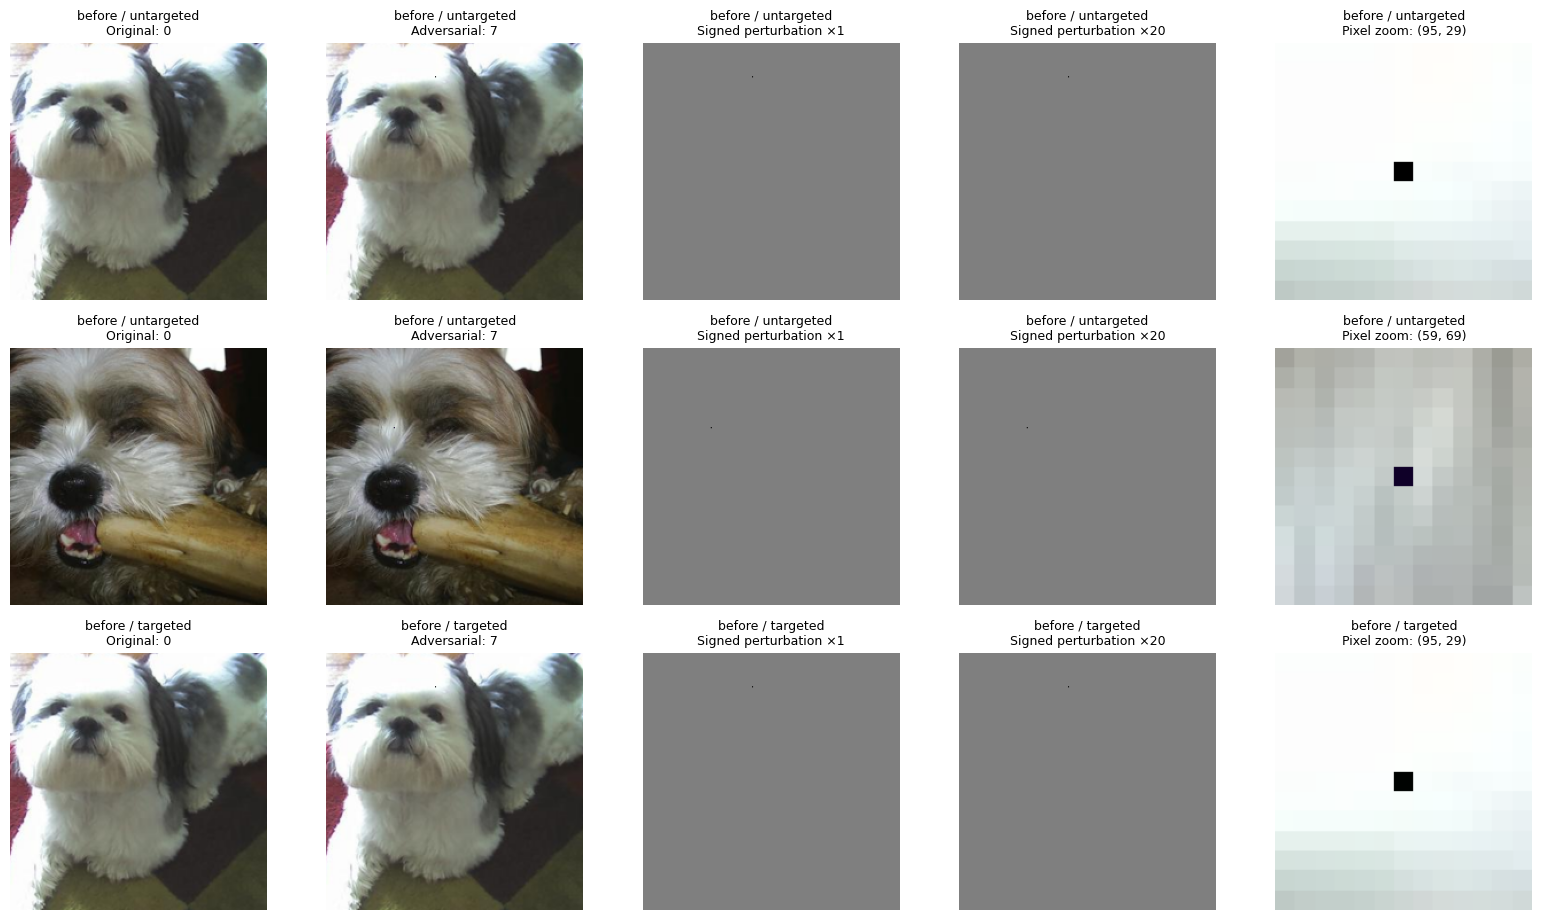

In [21]:
def signed_perturbation_image(delta, scale=1.0):
    return np.clip(0.5 + scale * delta, 0.0, 1.0)


def pixel_zoom(image, x, y, radius=6, zoom_size=160):
    height, width, _ = image.shape
    left, right = max(0, x - radius), min(width, x + radius + 1)
    top, bottom = max(0, y - radius), min(height, y + radius + 1)
    crop = Image.fromarray(image[top:bottom, left:right])
    return np.asarray(crop.resize((zoom_size, zoom_size), Image.Resampling.NEAREST))


if not successful_examples:
    print('Успешных атак для визуализации не найдено.')
else:
    rows = len(successful_examples)
    fig, axes = plt.subplots(rows, 5, figsize=(16, 3.1 * rows), squeeze=False)
    for row, example in enumerate(successful_examples):
        original = example['original']
        adversarial = example['adversarial']
        delta = adversarial.astype(np.float32) / 255.0 - original.astype(np.float32) / 255.0
        x, y = example['x'], example['y']
        perturbation_x1 = signed_perturbation_image(delta, 1.0)
        perturbation_x20 = signed_perturbation_image(delta, 20.0)
        zoom = pixel_zoom(adversarial, x, y)
        images = [original, adversarial, perturbation_x1, perturbation_x20, zoom]
        titles = [
            f"Original: {example['true_class']}",
            f"Adversarial: {example['adversarial_prediction']}",
            'Signed perturbation ×1', 'Signed perturbation ×20', f'Pixel zoom: ({x}, {y})',
        ]
        example_dir = EXAMPLES_DIR / f"{example['model']}_{example['mode']}_sample_{example['sample_index']:02d}"
        example_dir.mkdir(parents=True, exist_ok=True)
        Image.fromarray(original).save(example_dir / 'original.png')
        Image.fromarray(adversarial).save(example_dir / 'adversarial.png')
        Image.fromarray((perturbation_x1 * 255).astype(np.uint8)).save(example_dir / 'perturbation_x1.png')
        Image.fromarray((perturbation_x20 * 255).astype(np.uint8)).save(example_dir / 'perturbation_x20.png')
        Image.fromarray(zoom).save(example_dir / 'pixel_zoom.png')
        np.save(example_dir / 'perturbation_raw.npy', delta)
        with (example_dir / 'metadata.json').open('w', encoding='utf-8') as file:
            json.dump({key: value for key, value in example.items() if key not in {'original', 'adversarial'}}, file, ensure_ascii=False, indent=2)
        for axis, image, title in zip(axes[row], images, titles):
            axis.imshow(image)
            axis.set_title(f"{example['model']} / {example['mode']}\n{title}", fontsize=9)
            axis.axis('off')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'successful_examples.png', dpi=160, bbox_inches='tight')
    plt.show()

## Финальные проверки и сохранённые файлы

In [22]:
fingerprints_after = {name: model_fingerprint(net) for name, net in models_by_name.items()}
assert fingerprints_after == fingerprints_before, 'Атака изменила веса модели'
assert len(results_df) == len(models_by_name) * 2 * MAX_ATTACK_SAMPLES
assert results_df['changed_pixels'].le(1).all()
assert (results_df['clean_prediction'] == results_df['true_class']).all()
required_outputs = [
    OUTPUT_DIR / 'onepixel_results.csv',
    OUTPUT_DIR / 'onepixel_summary.csv',
    OUTPUT_DIR / 'configuration.json',
    OUTPUT_DIR / 'onepixel_comparison.png',
]
for path in required_outputs:
    assert path.is_file(), path
print('Все проверки пройдены. Saved files:')
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file():
        print(' ', path)

Все проверки пройдены. Saved files:
  /kaggle/working/imagewoof_onepixel/configuration.json
  /kaggle/working/imagewoof_onepixel/examples/before_targeted_sample_01/adversarial.png
  /kaggle/working/imagewoof_onepixel/examples/before_targeted_sample_01/metadata.json
  /kaggle/working/imagewoof_onepixel/examples/before_targeted_sample_01/original.png
  /kaggle/working/imagewoof_onepixel/examples/before_targeted_sample_01/perturbation_raw.npy
  /kaggle/working/imagewoof_onepixel/examples/before_targeted_sample_01/perturbation_x1.png
  /kaggle/working/imagewoof_onepixel/examples/before_targeted_sample_01/perturbation_x20.png
  /kaggle/working/imagewoof_onepixel/examples/before_targeted_sample_01/pixel_zoom.png
  /kaggle/working/imagewoof_onepixel/examples/before_untargeted_sample_01/adversarial.png
  /kaggle/working/imagewoof_onepixel/examples/before_untargeted_sample_01/metadata.json
  /kaggle/working/imagewoof_onepixel/examples/before_untargeted_sample_01/original.png
  /kaggle/working/i